# 淘宝用户行为数据分析 - 核心指标体系

## 1. 加载数据

本Notebook用于计算和分析核心业务指标，包括PV、UV、转化率、复购率等。

In [1]:
import sys
sys.path.append('../src')

from data_loader import load_cleaned_data
from metrics import (
    calculate_pv, calculate_uv, calculate_purchase_count, calculate_purchase_users,
    calculate_cart_count, calculate_favorite_count, calculate_conversion_rate,
    calculate_cart_conversion, calculate_favorite_conversion, calculate_repurchase_rate,
    calculate_avg_purchase_freq, calculate_bounce_rate, get_metrics_summary,
    calculate_daily_metrics, calculate_hourly_metrics, calculate_category_metrics
)
from plot_utils import plot_daily_trend,plot_hourly_trend,plot_categories_top_n,metrics_summary

df = load_cleaned_data()
print(f'本次共加载{len(df)}条数据')

本次共加载9039480条数据


## 2.核心指标计算

In [2]:
summary = get_metrics_summary(df)
print("=== 核心指标概览 ===")
print(f"页面浏览量 (PV): {summary['pv']:,}")
print(f"独立访客数 (UV): {summary['uv']:,}")
print(f"购买次数: {summary['purchases']:,}")
print(f"购买用户数: {summary['purchase_users']:,}")
print(f"加购物车次数: {summary['carts']:,}")
print(f"收藏次数: {summary['favorites']:,}")
print(f"\n=== 转化指标 ===")
print(f"浏览到购买转化率: {summary['pv_conversion_rate']:.2f}")
print(f"加购物车到购买转化率: {summary['cart_conversion_rate']:.2f}")
print(f"收藏到购买转化率: {summary['favorite_conversion_rate']:.2f}")
print(f"\n=== 用户质量指标 ===")
print(f"复购率: {summary['repurchase_rate']:.2f}")
print(f"平均每个用户购买频次: {summary['avg_purchase_freq']:.2f}")
print(f"跳出率: {summary['bounce_rate']:.4f}")

=== 核心指标概览 ===
页面浏览量 (PV): 8,326,149
独立访客数 (UV): 10,000
购买次数: 112,939
购买用户数: 8,886
加购物车次数: 255,543
收藏次数: 344,849

=== 转化指标 ===
浏览到购买转化率: 0.01
加购物车到购买转化率: 0.44
收藏到购买转化率: 0.33

=== 用户质量指标 ===
复购率: 0.87
平均每个用户购买频次: 12.71
跳出率: 0.0007


指标数据可视化(pv值远远大于其他指标，这里为了方便查看其他数据，不展示pv值)

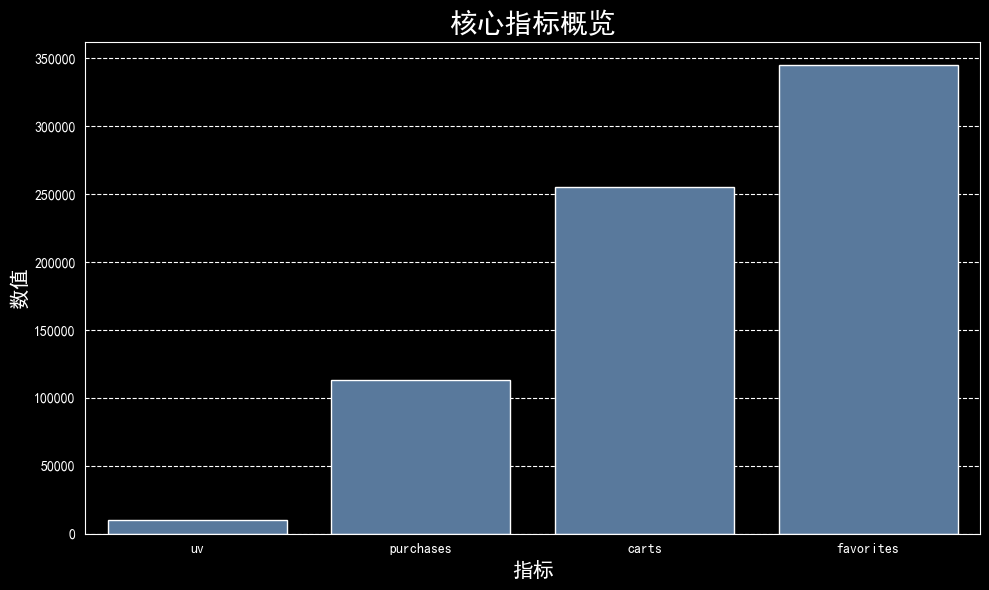

In [3]:
metrics_summary(summary)

## 3.每日趋势分析

In [4]:
daily = calculate_daily_metrics(df)
print(daily)

          date      pv    uv  purchase   cart  favorite  pv_conversion_rate  \
0   2014-11-18  229298  6343      3416   6797      9819            0.538546   
1   2014-11-19  277690  6420      3369   7079      9608            0.524766   
2   2014-11-20  219731  6333      3171   7066      9552            0.500711   
3   2014-11-21  208476  6276      2723   6722      8329            0.433875   
4   2014-11-22  227508  6187      3208   7134      9493            0.518507   
5   2014-11-23  234564  6373      3089   7722      9990            0.484701   
6   2014-11-24  241477  6513      3149   7933      9863            0.483495   
7   2014-11-25  225398  6351      3180   7347      9540            0.500709   
8   2014-11-26  214382  6357      3271   7302      9128            0.514551   
9   2014-11-27  238516  6359      3385   7666      9806            0.532316   
10  2014-11-28  220973  6189      2964   6449      8839            0.478914   
11  2014-11-29  219788  6224      2954   7164      9

pv可视化分布

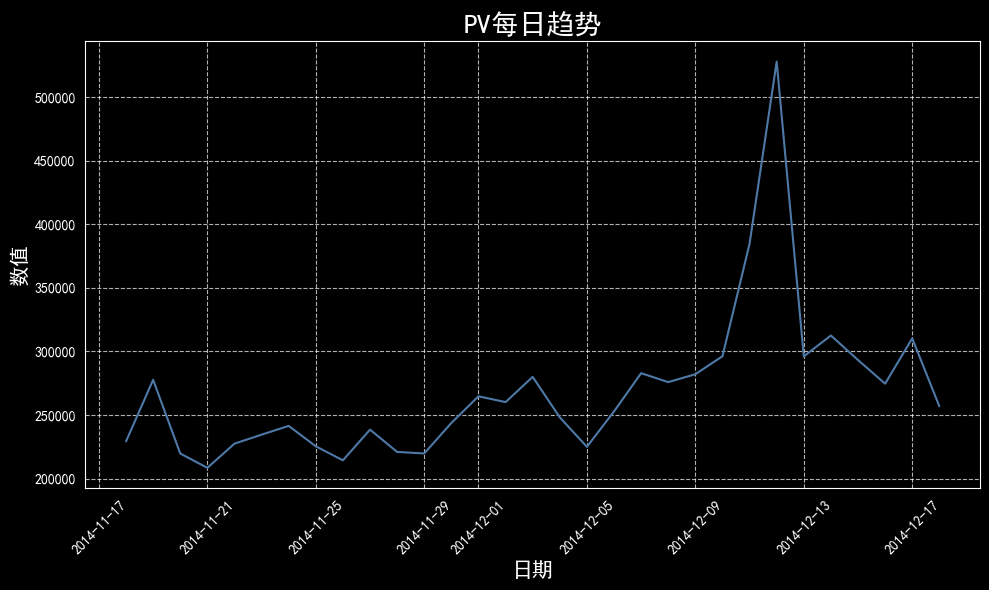

In [5]:
plot_daily_trend(daily,'pv')

purchase可视化分布

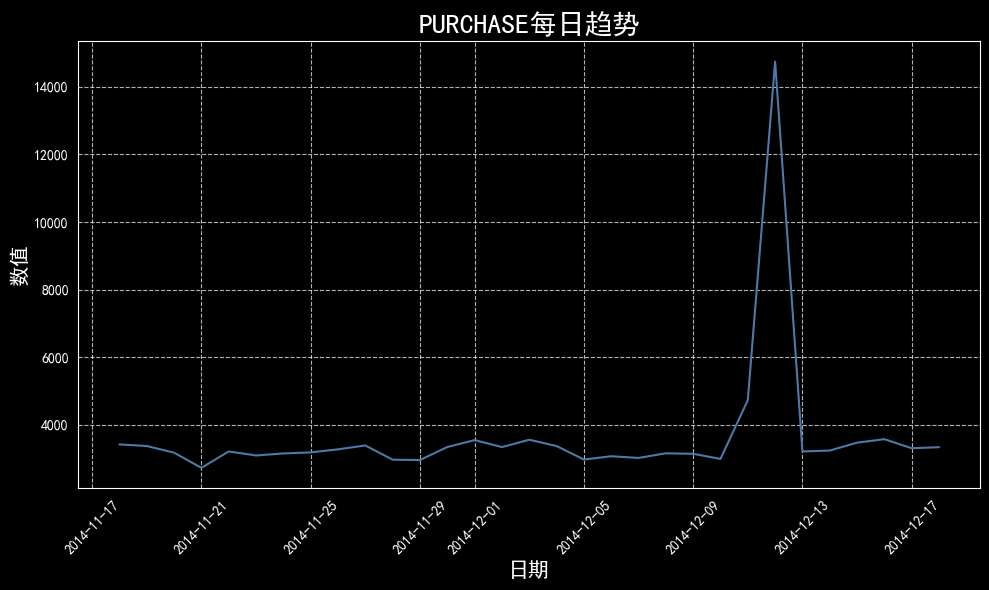

In [6]:
plot_daily_trend(daily,'purchase')

## 4.小时趋势分析

In [7]:
hourly = calculate_hourly_metrics(df)
print(hourly)

    hour      pv    uv  purchase   cart  favorite  pv_conversion_rate  \
0      0  262841  5786      4405  11019     13652            0.761320   
1      1  143509  3780      1549   6383      6595            0.409788   
2      2   76668  2532       726   3279      3853            0.286730   
3      3   48374  1937       450   2250      2378            0.232318   
4      4   42195  1765       367   2549      2091            0.207932   
5      5   47716  2030       422   2179      2147            0.207882   
6      6   78889  3564       941   3590      3716            0.264029   
7      7  198115  5722      1836   5997      6862            0.320867   
8      8  281762  7108      3509   7785      9727            0.493669   
9      9  334695  7734      5229  11163     12757            0.676106   
10    10  380392  8139      6767  12758     15727            0.831429   
11    11  358495  8239      6668  10893     17100            0.809322   
12    12  408957  8314      6342  13446     14687  

pv可视化分布

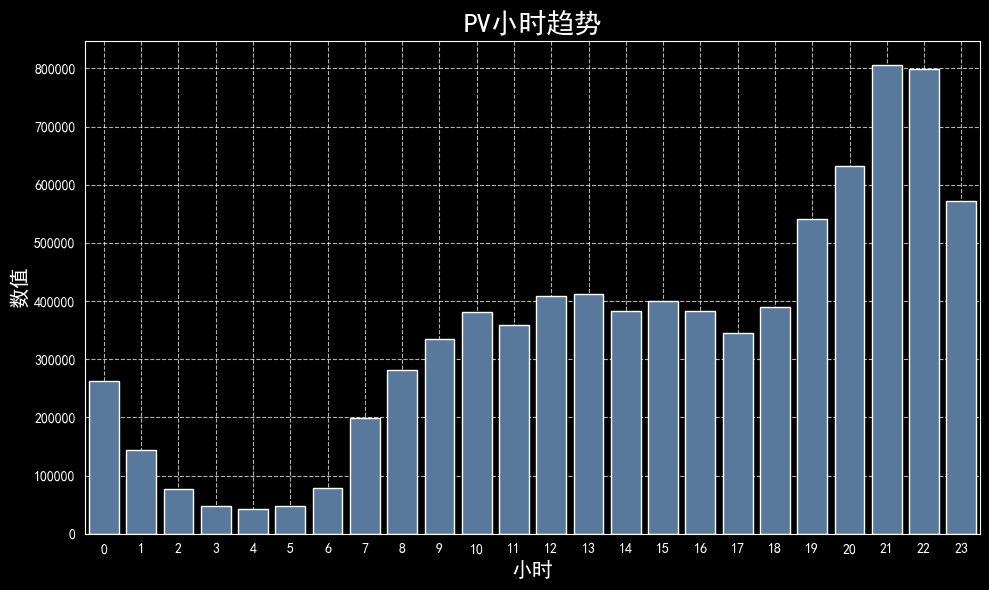

In [8]:
plot_hourly_trend(hourly,'pv')

purchases可视化分布

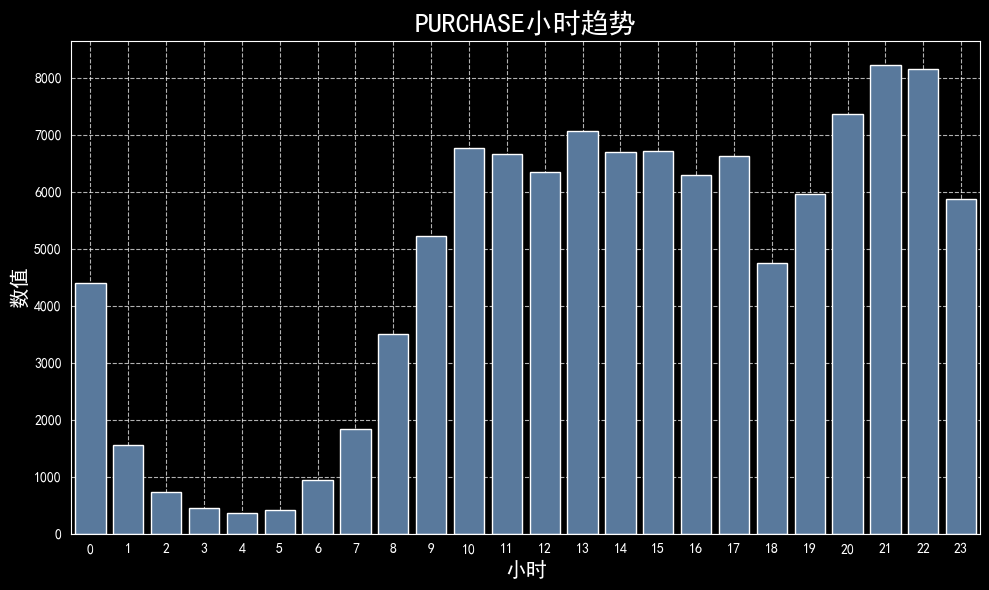

In [9]:
plot_hourly_trend(hourly,'purchase')

## 5.商品类别分析

In [10]:
category_df = calculate_category_metrics(df)
print('top10 品类')
print(category_df.head(10))

top10 品类
      item_category      pv    uv  purchases  carts  favorites  \
1136           1863  242793  5997       1936  10134       9167   
7646          12090  215644  1783       1837   7457       9935   
3985           6344   52983  4157       1661   1654       3534   
3284           5232   87724  4972       1468   2578       4368   
4394           6977   15653   716       1086    267       1950   
3394           5399  178107  5312       1030   6567       5342   
4094           6513  182251  5288       1025   6655       6530   
2132           3424   34330  2478        969    771       1448   
5579           8877   39214  2309        966   1245       1907   
3708           5894  202436  5279        941   7810       6490   

      pv_conversion_rate  pv_share  purchase_share  
1136            0.322828  0.029160        0.017142  
7646            1.030286  0.025900        0.016265  
3985            0.399567  0.006363        0.014707  
3284            0.295253  0.010536        0.012998  

top10 品类分析

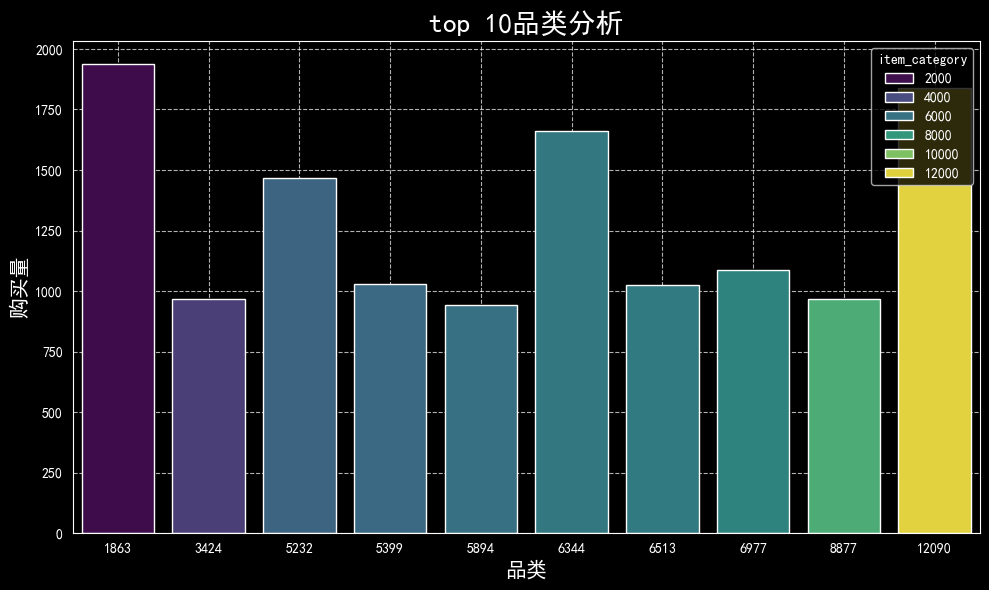

In [11]:
plot_categories_top_n(category_df,10)